# Grouping

## References

https://wesmckinney.com/book/data-aggregation

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.DataFrame(
    {
        "key1" : ["a", "a", None, "b", "b", "a", None],
        "key2" : pd.Series([1, 2, 1, 2, 1, None, 1],dtype="Int64"),
        "data1" : np.random.standard_normal(7),
        "data2" : np.random.standard_normal(7)
    }
)



In [4]:
df

,key1,key2,data1,data2
0,a,1,-0.214571,-0.596721
1,a,2,0.122608,-0.141611
2,None,1,-0.200303,0.001376
3,b,2,0.601658,0.177921
4,b,1,-1.154291,0.506682
5,a,<NA>,0.042874,-0.455777
6,None,1,-0.206848,-0.210765


## Grouping by one Key

In [5]:
grouped=df.groupby(by="key1")["data1"]
grouped

In [7]:
grouped.mean()

key1
a   -0.016363
b   -0.276317
Name: data1, dtype: float64

## Group by two Keys

In [8]:
means=df.groupby(by=["key1", "key2"])["data1"].mean()

In [9]:
means

key1  key2
a     1      -0.214571
      2       0.122608
b     1      -1.154291
      2       0.601658
Name: data1, dtype: float64

## Grouping with Arrays

In [10]:
states = np.array(["OH", "CA", "CA", "OH", "OH", "CA", "OH"])
years = [2005, 2005, 2006, 2005, 2006, 2005, 2006]

In [11]:
df.groupby(by=[states, years])["data1"].mean()

CA  2005    0.082741
    2006   -0.200303
OH  2005    0.193543
    2006   -0.680570
Name: data1, dtype: float64

## Counting Elements in a Group

In [10]:
sizes=df.groupby(by=["key1"])["data1"].size()
sizes

key1
a    3
b    2
Name: data1, dtype: int64

In [11]:
sizes=df.groupby(by=["key1"])["data1"].count()
sizes

key1
a    3
b    2
Name: data1, dtype: int64

## Not droping na values

In [12]:
sizes=df.groupby(by=["key1"], dropna=False)["data1"].count()
sizes

key1
a      3
b      2
NaN    2
Name: data1, dtype: int64

## Iterating Ovrer Groups

In [13]:
groups=df.groupby(by=["key1"], dropna=False)["data1"]
for name, group in groups:
    print(name)
    print(group)
    print(group.mean())

a
0   -0.355095
1   -0.234304
5    0.767798
Name: data1, dtype: float64
0.05946650160538969
b
3    0.312421
4   -2.675688
Name: data1, dtype: float64
-1.1816337951475446
nan
2   -0.401303
6   -0.779112
Name: data1, dtype: float64
-0.5902078327226661


## Moving groups to a dictionary

In [14]:
groups=df.groupby(by="key1", dropna=False)

pieces = {name: group for name, group in groups}

In [15]:
pieces["b"]

,key1,key2,data1,data2
3,b,2,0.312421,-1.150141
4,b,1,-2.675688,0.334323


## Grouping by Columns axes

In [16]:
grouped = df.groupby({"key1": "key", "key2": "key", "data1": "data", "data2": "data"}, axis="columns")

In [17]:
for group_key, group_name in grouped:
    print(group_key)
    print(group_name)

data
      data1     data2
0 -0.355095 -1.639289
1 -0.234304 -0.612367
2 -0.401303 -0.577743
3  0.312421 -1.150141
4 -2.675688  0.334323
5  0.767798 -0.349753
6 -0.779112  0.652330
key
   key1  key2
0     a     1
1     a     2
2  None     1
3     b     2
4     b     1
5     a  <NA>
6  None     1


In [18]:
df

,key1,key2,data1,data2
0,a,1,-0.355095,-1.639289
1,a,2,-0.234304,-0.612367
2,None,1,-0.401303,-0.577743
3,b,2,0.312421,-1.150141
4,b,1,-2.675688,0.334323
5,a,<NA>,0.767798,-0.349753
6,None,1,-0.779112,0.652330


## Grouping with Dictionaries and Series

In [19]:
people = pd.DataFrame(np.random.standard_normal((5, 5)), columns=["a", "b", "c", "d", "e"], index=["Joe", "Steve", "Wanda", "Jill", "Trey"])

people.iloc[2:3, [1, 2]] = np.nan # Add a few NA values


In [20]:
people

,a,b,c,d,e
Joe,-1.763170,0.486521,-0.631294,-0.305582,-0.419449
Steve,-0.737595,-1.032399,1.441979,0.067358,-0.794419
Wanda,-0.005258,NaN,NaN,-0.265963,0.949717
Jill,-0.367709,-1.029405,0.457581,1.294087,0.311921
Trey,-0.279939,0.488154,-0.152650,0.310593,0.291935


In [21]:
mapping = {"a": "red", "b": "red", "c": "blue", "d": "blue", "e": "red", "f" : "orange"}

In [22]:
by_column = people.groupby(by=mapping, axis="columns")

In [23]:
by_column.sum()

,blue,red
Joe,-0.936875,-1.696098
Steve,1.509337,-2.564412
Wanda,-0.265963,0.944459
Jill,1.751668,-1.085193
Trey,0.157942,0.500150


### Using Series

In [24]:
series_mapping = pd.Series(mapping)
by_column = people.groupby(by=series_mapping, axis="columns").sum()
by_column

,blue,red
Joe,-0.936875,-1.696098
Steve,1.509337,-2.564412
Wanda,-0.265963,0.944459
Jill,1.751668,-1.085193
Trey,0.157942,0.500150


In [25]:
people

,a,b,c,d,e
Joe,-1.763170,0.486521,-0.631294,-0.305582,-0.419449
Steve,-0.737595,-1.032399,1.441979,0.067358,-0.794419
Wanda,-0.005258,NaN,NaN,-0.265963,0.949717
Jill,-0.367709,-1.029405,0.457581,1.294087,0.311921
Trey,-0.279939,0.488154,-0.152650,0.310593,0.291935


### Grouping with functions

In [26]:
people.groupby(by=len).sum()

,a,b,c,d,e
3,-1.763170,0.486521,-0.631294,-0.305582,-0.419449
4,-0.647647,-0.541251,0.304931,1.604679,0.603855
5,-0.742852,-1.032399,1.441979,-0.198605,0.155298


### Grouping with functions and series

In [27]:
key_list = ["one", "one", "one", "two", "two"]
people.groupby(by=[len, key_list]).sum()

,,a,b,c,d,e
3,one,-1.763170,0.486521,-0.631294,-0.305582,-0.419449
4,two,-0.647647,-0.541251,0.304931,1.604679,0.603855
5,one,-0.742852,-1.032399,1.441979,-0.198605,0.155298


In [28]:
people["value"] = key_list

In [29]:
people.groupby(by=[len, "value"]).sum()

,,a,b,c,d,e
,value,,,,,
3,one,-1.763170,0.486521,-0.631294,-0.305582,-0.419449
4,two,-0.647647,-0.541251,0.304931,1.604679,0.603855
5,one,-0.742852,-1.032399,1.441979,-0.198605,0.155298


In [30]:
people

,a,b,c,d,e,value
Joe,-1.763170,0.486521,-0.631294,-0.305582,-0.419449,one
Steve,-0.737595,-1.032399,1.441979,0.067358,-0.794419,one
Wanda,-0.005258,NaN,NaN,-0.265963,0.949717,one
Jill,-0.367709,-1.029405,0.457581,1.294087,0.311921,two
Trey,-0.279939,0.488154,-0.152650,0.310593,0.291935,two


### Group by MUlti Index

In [31]:
columns = pd.MultiIndex.from_arrays([["US", "US", "US", "JP", "JP"],[1, 3, 5, 1, 3]], names=["cty", "tenor"])
hier_df = pd.DataFrame(np.random.standard_normal((4, 5)), columns=columns)

In [32]:
hier_df

cty          US                            JP          
tenor         1         3         5         1         3
0     -1.387033  2.242347  2.258221 -0.150233 -0.850977
1     -0.289303  1.588284 -0.727262 -0.491706 -1.638485
2     -1.407465  0.399748 -0.697517  1.257553  1.788762
3      0.838835  0.115210  0.027686  0.691434 -0.637712

In [33]:
hier_df.groupby(level="cty", axis="columns").count()

cty,JP,US
0,2,3
1,2,3
2,2,3
3,2,3


## Data Aggregation

In [34]:
df

,key1,key2,data1,data2
0,a,1,-0.355095,-1.639289
1,a,2,-0.234304,-0.612367
2,None,1,-0.401303,-0.577743
3,b,2,0.312421,-1.150141
4,b,1,-2.675688,0.334323
5,a,<NA>,0.767798,-0.349753
6,None,1,-0.779112,0.652330


### Some Optimized Aggregations

In [35]:
date_index = pd.date_range(start="2022-01-01 00:00", end="2023-09-01 00:00", freq="h")
price = pd.DataFrame(np.random.normal(0, 0.0005, len(date_index)).cumsum(), index=date_index, columns=["Close"]) + 1.1300
price["month"] = price.index.strftime("%Y-%m")
price["weekday"] = price.index.weekday
price["return"] = price["Close"] - price["Close"].shift(1)
price.dropna(inplace=True)

In [36]:
price.head()

,Close,month,weekday,return
2022-01-01 01:00:00,1.129902,2022-01,5,-0.000552
2022-01-01 02:00:00,1.129025,2022-01,5,-0.000877
2022-01-01 03:00:00,1.128692,2022-01,5,-0.000333
2022-01-01 04:00:00,1.129118,2022-01,5,0.000426
2022-01-01 05:00:00,1.129645,2022-01,5,0.000527


<Axes: >

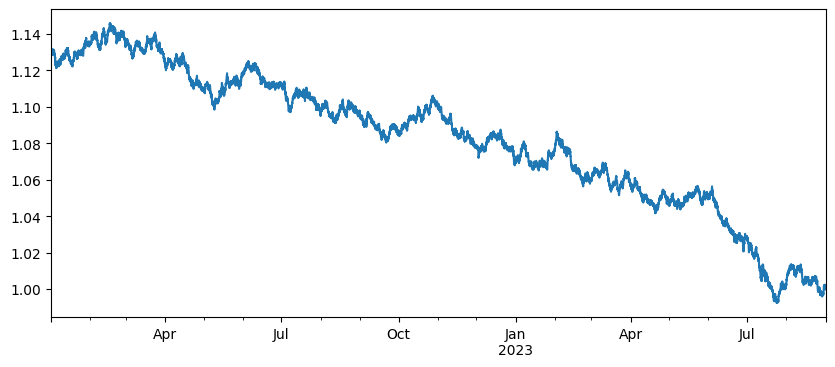

In [37]:
price["Close"].plot(figsize=(10,4))

In [38]:
price.groupby(by="month").mean()

,Close,weekday,return
month,,,
2022-01,1.128697,3.061911,4.793966e-06
2022-02,1.138749,3.000000,5.939758e-07
2022-03,1.132974,2.903226,-1.571703e-05
2022-04,1.119779,3.100000,-1.844848e-05
2022-05,1.110160,2.935484,1.032299e-05
2022-06,1.116381,2.966667,-7.422509e-06
2022-07,1.104990,3.193548,-2.203180e-05
2022-08,1.097835,2.806452,-4.116235e-07
2022-09,1.088836,3.033333,-1.095372e-05


In [39]:
grouped_by_monthy = price.groupby(by="month")

In [40]:
grouped_by_monthy["Close"].nsmallest(2)

month                       
2022-01  2022-01-05 12:00:00    1.121261
         2022-01-05 15:00:00    1.121543
2022-02  2022-02-08 19:00:00    1.131271
         2022-02-08 18:00:00    1.131308
2022-03  2022-03-31 22:00:00    1.122581
         2022-03-31 21:00:00    1.122659
2022-04  2022-04-29 23:00:00    1.108820
         2022-04-30 11:00:00    1.108988
2022-05  2022-05-09 13:00:00    1.098480
         2022-05-09 14:00:00    1.098994
2022-06  2022-06-26 03:00:00    1.109362
         2022-06-21 19:00:00    1.109687
2022-07  2022-07-31 20:00:00    1.095158
         2022-07-31 21:00:00    1.095208
2022-08  2022-08-12 20:00:00    1.091081
         2022-08-12 02:00:00    1.091180
2022-09  2022-09-21 09:00:00    1.080375
         2022-09-21 08:00:00    1.080585
2022-10  2022-10-01 17:00:00    1.083969
         2022-10-01 18:00:00    1.084102
2022-11  2022-11-30 22:00:00    1.077495
         2022-11-29 22:00:00    1.077523
2022-12  2022-12-31 03:00:00    1.067869
         2022-12-31 04:00:00

In [41]:
grouped_by_monthy["Close"].quantile(0.9)

month
2022-01    1.134148
2022-02    1.142896
2022-03    1.137022
2022-04    1.126475
2022-05    1.115289
2022-06    1.122844
2022-07    1.109886
2022-08    1.101523
2022-09    1.094337
2022-10    1.102579
2022-11    1.096069
2022-12    1.084588
2023-01    1.077104
2023-02    1.081084
2023-03    1.065826
2023-04    1.056723
2023-05    1.053178
2023-06    1.050729
2023-07    1.022464
2023-08    1.011870
2023-09    0.999774
Name: Close, dtype: float64

<Axes: >

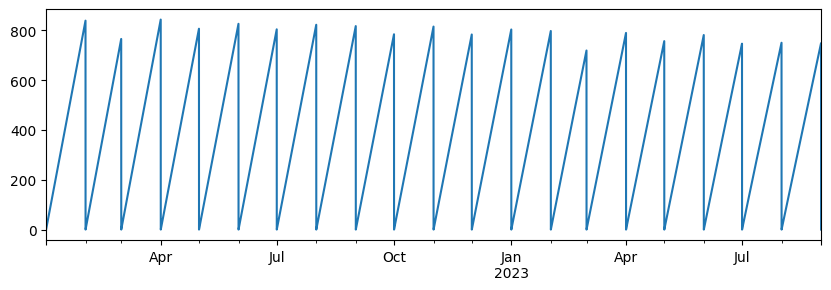

In [42]:
grouped_by_monthy["Close"].cumsum().plot(figsize=(10,3))

In [43]:
grouped_by_monthy["Close"].describe()

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
2022-01,743.0,1.128697,0.003575,1.121261,1.126227,1.128813,1.130626,1.137817
2022-02,672.0,1.138749,0.003241,1.131271,1.136325,1.139103,1.140952,1.146004
2022-03,744.0,1.132974,0.003300,1.122581,1.130748,1.133203,1.135276,1.140865
2022-04,720.0,1.119779,0.006002,1.108820,1.113089,1.121944,1.124912,1.129625
2022-05,744.0,1.110160,0.004595,1.098480,1.107354,1.111333,1.113410,1.118915
2022-06,720.0,1.116381,0.004615,1.109362,1.112145,1.114896,1.120953,1.125060
2022-07,744.0,1.104990,0.003955,1.095158,1.102250,1.105434,1.107618,1.113881
2022-08,744.0,1.097835,0.002911,1.091081,1.095634,1.097879,1.100153,1.104048
2022-09,720.0,1.088836,0.003860,1.080375,1.086040,1.089023,1.091323,1.097167


### Column-wise and multiple function application

In [44]:
grouped_price = price.groupby(["month", "weekday"])

In [45]:
grouped_price.describe()

Close                                                    \
                 count      mean       std       min       25%       50%   
month   weekday                                                            
2022-01 0        120.0  1.129085  0.003489  1.122798  1.126997  1.129131   
        1         96.0  1.127344  0.002474  1.122170  1.125196  1.127851   
        2         96.0  1.127304  0.003054  1.121261  1.124993  1.128385   
        3         96.0  1.129102  0.003934  1.122119  1.127196  1.129977   
        4         96.0  1.129457  0.004440  1.122297  1.126118  1.129427   
...                ...       ...       ...       ...       ...       ...   
2023-08 3        120.0  1.006859  0.004045  0.999853  1.004333  1.006002   
        4         96.0  1.007572  0.004143  0.998948  1.003932  1.007971   
        5         96.0  1.006716  0.005389  0.998480  1.002418  1.007501   
        6         96.0  1.005346  0.005303  0.996535  1.001596  1.003551   
2023-09 4          1.0  0.999774       NaN  0.999774  0.999774  0.999774   

                                    return                                \
                      75%       max  count      mean       std       min   
month   weekday                                                            
2022-01 0        1.130855  1.136008  120.0  0.000007  0.000471 -0.001094   
        1        1.129197  1.131356   96.0 -0.000039  0.000535 -0.001740   
        2        1.129400  1.131943   96.0  0.000092  0.000499 -0.001107   
        3        1.132080  1.134734   96.0  0.000001  0.000475 -0.001051   
        4        1.132321  1.137762   96.0  0.000019  0.000457 -0.001123   
...                   ...       ...    ...       ...       ...       ...   
2023-08 3        1.011011  1.012805  120.0 -0.000013  0.000564 -0.001596   
        4        1.011210  1.013031   96.0 -0.000059  0.000566 -0.001312   
        5        1.011699  1.013640   96.0  0.000019  0.000494 -0.001281   
        6        1.010972  1.013144   96.0 -0.000113  0.000437 -0.000901   
2023-09 4        0.999774  0.999774    1.0 -0.000079       NaN -0.000079   

                                                         
                      25%       50%       75%       max  
month   weekday                                          
2022-01 0       -0.000321 -0.000045  0.000305  0.001290  
        1       -0.000346  0.000034  0.000362  0.001154  
        2       -0.000155  0.000072  0.000434  0.001325  
        3       -0.000295 -0.000006  0.000269  0.001399  
        4       -0.000240  0.000027  0.000312  0.001589  
...                   ...       ...       ...       ...  
2023-08 3       -0.000382 -0.000036  0.000376  0.001658  
        4       -0.000418 -0.000075  0.000248  0.001405  
        5       -0.000246 -0.000021  0.000344  0.001472  
        6       -0.000472 -0.000144  0.000140  0.001135  
2023-09 4       -0.000079 -0.000079 -0.000079 -0.000079  

[141 rows x 16 columns]

In [46]:
# apply multiple functions
grouped_price.agg(["min", "max", "mean" ])

Close                        return                    
                      min       max      mean       min       max      mean
month   weekday                                                            
2022-01 0        1.122798  1.136008  1.129085 -0.001094  0.001290  0.000007
        1        1.122170  1.131356  1.127344 -0.001740  0.001154 -0.000039
        2        1.121261  1.131943  1.127304 -0.001107  0.001325  0.000092
        3        1.122119  1.134734  1.129102 -0.001051  0.001399  0.000001
        4        1.122297  1.137762  1.129457 -0.001123  0.001589  0.000019
...                   ...       ...       ...       ...       ...       ...
2023-08 3        0.999853  1.012805  1.006859 -0.001596  0.001658 -0.000013
        4        0.998948  1.013031  1.007572 -0.001312  0.001405 -0.000059
        5        0.998480  1.013640  1.006716 -0.001281  0.001472  0.000019
        6        0.996535  1.013144  1.005346 -0.000901  0.001135 -0.000113
2023-09 4        0.999774  0.999774  0.999774 -0.000079 -0.000079 -0.000079

[141 rows x 6 columns]

In [47]:
# changing column names
grouped_price.agg([("minimum", "min"), ("maximum", "max"), ("average", "mean"), ("range", lambda x: max(x)-min(x)) ])

Close                                  return            \
                  minimum   maximum   average     range   minimum   maximum   
month   weekday                                                               
2022-01 0        1.122798  1.136008  1.129085  0.013211 -0.001094  0.001290   
        1        1.122170  1.131356  1.127344  0.009186 -0.001740  0.001154   
        2        1.121261  1.131943  1.127304  0.010682 -0.001107  0.001325   
        3        1.122119  1.134734  1.129102  0.012616 -0.001051  0.001399   
        4        1.122297  1.137762  1.129457  0.015466 -0.001123  0.001589   
...                   ...       ...       ...       ...       ...       ...   
2023-08 3        0.999853  1.012805  1.006859  0.012953 -0.001596  0.001658   
        4        0.998948  1.013031  1.007572  0.014083 -0.001312  0.001405   
        5        0.998480  1.013640  1.006716  0.015160 -0.001281  0.001472   
        6        0.996535  1.013144  1.005346  0.016610 -0.000901  0.001135   
2023-09 4        0.999774  0.999774  0.999774  0.000000 -0.000079 -0.000079   

                                     
                  average     range  
month   weekday                      
2022-01 0        0.000007  0.002384  
        1       -0.000039  0.002894  
        2        0.000092  0.002432  
        3        0.000001  0.002450  
        4        0.000019  0.002713  
...                   ...       ...  
2023-08 3       -0.000013  0.003254  
        4       -0.000059  0.002717  
        5        0.000019  0.002752  
        6       -0.000113  0.002037  
2023-09 4       -0.000079  0.000000  

[141 rows x 8 columns]

In [48]:
# apply multiple functions by group of columns
result = grouped_price[["Close", "return"]].agg(["mean", "std", "min", "max"])
result

Close                                  return            \
                     mean       std       min       max      mean       std   
month   weekday                                                               
2022-01 0        1.129085  0.003489  1.122798  1.136008  0.000007  0.000471   
        1        1.127344  0.002474  1.122170  1.131356 -0.000039  0.000535   
        2        1.127304  0.003054  1.121261  1.131943  0.000092  0.000499   
        3        1.129102  0.003934  1.122119  1.134734  0.000001  0.000475   
        4        1.129457  0.004440  1.122297  1.137762  0.000019  0.000457   
...                   ...       ...       ...       ...       ...       ...   
2023-08 3        1.006859  0.004045  0.999853  1.012805 -0.000013  0.000564   
        4        1.007572  0.004143  0.998948  1.013031 -0.000059  0.000566   
        5        1.006716  0.005389  0.998480  1.013640  0.000019  0.000494   
        6        1.005346  0.005303  0.996535  1.013144 -0.000113  0.000437   
2023-09 4        0.999774       NaN  0.999774  0.999774 -0.000079       NaN   

                                     
                      min       max  
month   weekday                      
2022-01 0       -0.001094  0.001290  
        1       -0.001740  0.001154  
        2       -0.001107  0.001325  
        3       -0.001051  0.001399  
        4       -0.001123  0.001589  
...                   ...       ...  
2023-08 3       -0.001596  0.001658  
        4       -0.001312  0.001405  
        5       -0.001281  0.001472  
        6       -0.000901  0.001135  
2023-09 4       -0.000079 -0.000079  

[141 rows x 8 columns]

In [49]:
# select calculations for one group
result["Close"]

mean       std       min       max
month   weekday                                        
2022-01 0        1.129085  0.003489  1.122798  1.136008
        1        1.127344  0.002474  1.122170  1.131356
        2        1.127304  0.003054  1.121261  1.131943
        3        1.129102  0.003934  1.122119  1.134734
        4        1.129457  0.004440  1.122297  1.137762
...                   ...       ...       ...       ...
2023-08 3        1.006859  0.004045  0.999853  1.012805
        4        1.007572  0.004143  0.998948  1.013031
        5        1.006716  0.005389  0.998480  1.013640
        6        1.005346  0.005303  0.996535  1.013144
2023-09 4        0.999774       NaN  0.999774  0.999774

[141 rows x 4 columns]

In [50]:
# apply differnt functions to differnt columns passing a dictionary

grouped_price.agg({"Close": [("daily average", "mean"), "std"], "return":"std"})

Close              return
                daily average       std       std
month   weekday                                  
2022-01 0            1.129085  0.003489  0.000471
        1            1.127344  0.002474  0.000535
        2            1.127304  0.003054  0.000499
        3            1.129102  0.003934  0.000475
        4            1.129457  0.004440  0.000457
...                       ...       ...       ...
2023-08 3            1.006859  0.004045  0.000564
        4            1.007572  0.004143  0.000566
        5            1.006716  0.005389  0.000494
        6            1.005346  0.005303  0.000437
2023-09 4            0.999774       NaN       NaN

[141 rows x 3 columns]

In [161]:
# build profits dataset

date_index = pd.date_range(start="2019-01-01", end="2023-09-01", freq="D")
profits = pd.DataFrame(np.random.normal(5, 100, len(date_index)), index=date_index, columns=["returns"])

profits["week-day"] = profits.index.weekday
profits["month"] = pd.to_datetime(profits.index.strftime("%Y-%m"))
profits["month-num"] = profits.index.month
profits["year"] = profits.index.year

In [118]:
profits.head()

,returns,week-day,month,month-num,year
2019-01-01,32.539416,1,2019-01-01,1,2019
2019-01-02,-22.683731,2,2019-01-01,1,2019
2019-01-03,44.022067,3,2019-01-01,1,2019
2019-01-04,89.083801,4,2019-01-01,1,2019
2019-01-05,145.698876,5,2019-01-01,1,2019


In [119]:
grouped_month = profits.groupby(by="month")

In [135]:
grouped_month["returns"].agg(["min", "max", "mean"]).head()

,min,max,mean
month,,,
2019-01-01,-180.222421,225.111285,12.511572
2019-02-01,-222.177574,118.484479,-5.131066
2019-03-01,-167.379130,193.473122,1.510351
2019-04-01,-178.272106,227.355504,39.193024
2019-05-01,-161.318684,265.311109,-14.158190


In [126]:
grouped_by_month_num = profits.groupby(by=["month-num", "year"])

<Axes: xlabel='month-num,year'>

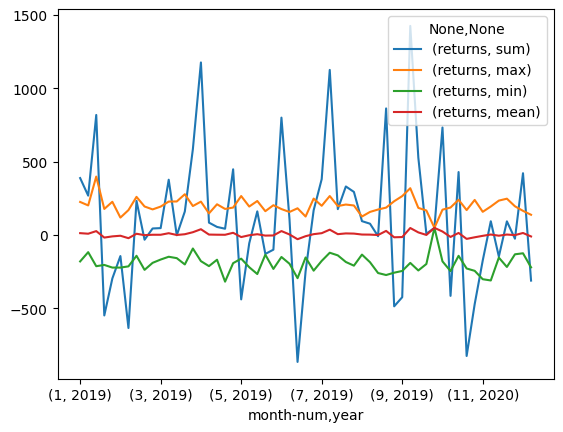

In [144]:
grouped_by_month_num[["returns"]].agg(["sum", "max", "min", "mean"]).plot()

### Supress indices when grouping

<Axes: xlabel='month-num,year'>

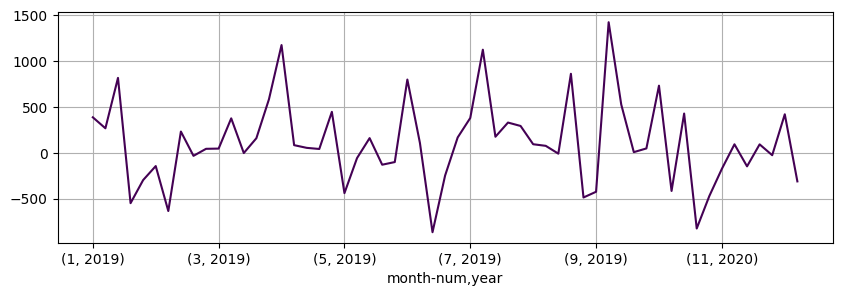

In [158]:
grouped_by_month_num = profits.groupby(by=["month-num", "year"], as_index=False)
grouped_by_month_num["returns"].agg(["sum", "max", "min", "mean"], numeric_only=True)["sum"].plot(figsize=(10,3), grid=True, cmap="viridis")

In [160]:
grouped_by_month_num["returns"].agg(["sum", "max", "min", "mean"], numeric_only=True).head()

sum         max         min       mean
month-num year                                               
1         2019  387.858726  225.111285 -180.222421  12.511572
          2020  268.185070  201.446247 -117.102383   8.651131
          2021  817.924407  397.952946 -212.754695  26.384658
          2022 -548.284030  177.381617 -204.077258 -17.686582
          2023 -296.279351  226.266951 -222.106148  -9.557398

## Apply: generl split - apply - combine

What is the difference between agg and apply?

In [163]:
date_index = pd.date_range(start="2019-01-01", end="2023-09-01", freq="D")
profits = pd.DataFrame(np.random.normal(5, 100, len(date_index)), index=date_index, columns=["returns"])

profits["day"] = profits.index.day
profits["week-day"] = profits.index.weekday
profits["month"] = pd.to_datetime(profits.index.strftime("%Y-%m"))
profits["month-num"] = profits.index.month
profits["year"] = profits.index.year

In [164]:
profits.head()

,returns,day,week-day,month,month-num,year
2019-01-01,21.136527,1,1,2019-01-01,1,2019
2019-01-02,-35.848311,2,2,2019-01-01,1,2019
2019-01-03,154.852703,3,3,2019-01-01,1,2019
2019-01-04,67.689292,4,4,2019-01-01,1,2019
2019-01-05,2.029919,5,5,2019-01-01,1,2019


### Return the top returning days in the month

In [166]:
def top(df: pd.DataFrame, n=3, column="returns"):
    return df.sort_values(by=column, ascending=False)[:3]

In [167]:
top(profits)

,returns,day,week-day,month,month-num,year
2020-06-29,351.154343,29,0,2020-06-01,6,2020
2020-08-18,346.329002,18,1,2020-08-01,8,2020
2020-12-31,301.335690,31,3,2020-12-01,12,2020


In [177]:
profits.groupby(["year", "month-num"], group_keys=True).apply(top)["returns"]

year  month-num            
2019  1          2019-01-30    176.684454
                 2019-01-16    163.539355
                 2019-01-03    154.852703
      2          2019-02-12    218.018881
                 2019-02-21    189.968043
                                  ...    
2023  7          2023-07-12    145.650982
      8          2023-08-26    211.369603
                 2023-08-23    196.438648
                 2023-08-24    161.100280
      9          2023-09-01     15.016165
Name: returns, Length: 169, dtype: float64